In [ ]:
# ==========================================================
# COVID-19 International Spread Analysis
# Dataset A - Cleaned Country Dataset
# Part 1: Loading & Descriptive Statistics
# ==========================================================

# ==========================================================
# 1. Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os

plt.style.use('ggplot')

# Make figures larger
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [ ]:
# ==========================================================
# 2. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================================
# 3. Load Dataset
# ==========================================================

file_path = "/content/Dataset_A_Clean_Country (2).csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
# ==========================================================
# Check Unique Continent Labels
# ==========================================================

print("Unique Continent Labels:\n")

print(df["Continent"].value_counts(dropna=False))

print("\n")

print(sorted(df["Continent"].dropna().unique()))

Unique Continent Labels:

Continent
Africa           53
Asia             45
Europe           44
North America    22
South America    14
Australia         4
Asia, Europe      3
Asia, Africa      1
Name: count, dtype: int64


['Africa', 'Asia', 'Asia, Africa', 'Asia, Europe', 'Australia', 'Europe', 'North America', 'South America']


In [ ]:
# ==========================================================
# Countries Having Multiple Continents
# ==========================================================

multiple_continent = df[
    df["Continent"].str.contains(",", na=False)
][["Country", "Continent"]]

display(multiple_continent)

print("Number of affected countries:", len(multiple_continent))

,Country,Continent
25,Egypt,"Asia, Africa"
40,Georgia,"Asia, Europe"
52,Azerbaijan,"Asia, Europe"
112,Turkey,"Asia, Europe"


Number of affected countries: 4


In [ ]:
# ==========================================================
# Standardize Continent Labels
# ==========================================================

continent_mapping = {

    "Asia, Europe": "Asia",

    "Europe, Asia": "Asia",

    "Asia, Africa": "Africa",

    "Africa, Asia": "Africa",

    "North America, South America": "North America",

    "South America, North America": "North America",

    "Europe, Africa": "Europe",

    "Africa, Europe": "Europe"

}

In [ ]:
# ==========================================================
# Standardize Continent Labels
# ==========================================================

continent_mapping = {

    "Asia, Europe": "Asia",

    "Europe, Asia": "Asia",

    "Asia, Africa": "Africa",

    "Africa, Asia": "Africa",

    "North America, South America": "North America",

    "South America, North America": "North America",

    "Europe, Africa": "Europe",

    "Africa, Europe": "Europe"

}

In [ ]:
# ==========================================================
# Replace Multiple Continents
# ==========================================================

df["Continent"] = df["Continent"].replace(continent_mapping)

In [ ]:
# ==========================================================
# Verify Corrected Labels
# ==========================================================

print(df["Continent"].value_counts())

print("\nUnique Labels:\n")

print(sorted(df["Continent"].unique()))

Continent
Africa           54
Asia             48
Europe           44
North America    22
South America    14
Australia         4
Name: count, dtype: int64

Unique Labels:

['Africa', 'Asia', 'Australia', 'Europe', 'North America', 'South America']


In [ ]:
# ==========================================================
# Save Corrected Dataset
# ==========================================================

output_path = "/content/drive/MyDrive/COVID/Dataset_A_Clean_Country_Corrected.csv"

df.to_csv(output_path, index=False)

print("Corrected dataset saved successfully.")

print(output_path)

Corrected dataset saved successfully.
/content/drive/MyDrive/COVID/Dataset_A_Clean_Country_Corrected.csv


In [ ]:
# ==========================================================
# 3. Load Dataset
# ==========================================================

file_path = "/content/drive/MyDrive/COVID/Dataset_A_Clean_Country_Corrected.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
# ==========================================================
# 4. Create Output Folders
# ==========================================================

output_folder = "/content/drive/MyDrive/COVID/Results"

tables_folder = os.path.join(output_folder,"Tables")
figures_folder = os.path.join(output_folder,"Figures")

os.makedirs(tables_folder, exist_ok=True)
os.makedirs(figures_folder, exist_ok=True)

print("Folders Created Successfully.")

Folders Created Successfully.


In [ ]:
# ==========================================================
# 5. Basic Dataset Information
# ==========================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nShape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nFirst Five Rows")
display(df.head())

DATASET INFORMATION

Shape of Dataset
(186, 8)

Columns
['Continent', 'Country', 'Date of First Case(s)', 'Last Visited Country(s) of Confirmed Case(s)', 'Confirmed Case(s) at First Day', 'Age of First Case(s)', 'Date of First Death(s)', 'Age of First Death(s)']

Data Types
Continent                                       object
Country                                         object
Date of First Case(s)                           object
Last Visited Country(s) of Confirmed Case(s)    object
Confirmed Case(s) at First Day                   int64
Age of First Case(s)                            object
Date of First Death(s)                          object
Age of First Death(s)                           object
dtype: object

Missing Values
Continent                                        0
Country                                          0
Date of First Case(s)                            0
Last Visited Country(s) of Confirmed Case(s)    13
Confirmed Case(s) at First Day                   0


,Continent,Country,Date of First Case(s),Last Visited Country(s) of Confirmed Case(s),Confirmed Case(s) at First Day,Age of First Case(s),Date of First Death(s),Age of First Death(s)
0,Asia,China,2019-11-17,Starting Country,1,55,NaN,NaN
1,Europe,France,2019-12-27,NaN,1,43,2020-02-15,80
2,Asia,Nepal,2020-01-13,China,1,32,2020-05-16,29
3,Asia,Thailand,2020-01-13,China,1,61,2020-03-01,35
4,Asia,Japan,2020-01-16,China,1,30+,2020-02-13,80+


In [ ]:
# ==========================================================
# 6. Statistical Summary
# ==========================================================

summary = df.describe(include='all')

display(summary)

summary.to_csv(
    os.path.join(tables_folder,"DatasetSummary.csv"),
    index=True
)

print("Dataset Summary Saved.")

,Continent,Country,Date of First Case(s),Last Visited Country(s) of Confirmed Case(s),Confirmed Case(s) at First Day,Age of First Case(s),Date of First Death(s),Age of First Death(s)
count,186,186,186,173,186.000000,119,160,129
unique,6,186,57,53,NaN,69,59,63
top,Africa,China,2020-03-13,Italy,NaN,50,2020-03-12,60
freq,54,1,13,43,NaN,5,9,7
mean,NaN,NaN,NaN,NaN,1.494624,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.291332,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN


Dataset Summary Saved.


In [ ]:
# ==========================================================
# 7. Country Frequency
# ==========================================================

country_freq = (
    df["Country"]
    .value_counts()
    .reset_index()
)

country_freq.columns = ["Country","Frequency"]

display(country_freq)

country_freq.to_csv(
    os.path.join(tables_folder,"CountryFrequency.csv"),
    index=False
)

,Country,Frequency
0,China,1
1,France,1
2,Nepal,1
3,Thailand,1
4,Japan,1
...,...,...
181,Sao Tome and Principe,1
182,Yemen,1
183,Comoros,1
184,Tajikistan,1


In [ ]:
# ==========================================================
# 8. Continent Frequency
# ==========================================================

continent_freq = (
    df["Continent"]
    .value_counts()
    .reset_index()
)

continent_freq.columns = ["Continent","Frequency"]

display(continent_freq)

continent_freq.to_csv(
    os.path.join(tables_folder,"ContinentFrequency.csv"),
    index=False
)

,Continent,Frequency
0,Africa,54
1,Asia,48
2,Europe,44
3,North America,22
4,South America,14
5,Australia,4


In [ ]:
# ==========================================================
# 9. Convert Date Columns
# ==========================================================

df["Date of First Case(s)"] = pd.to_datetime(
    df["Date of First Case(s)"],
    errors="coerce"
)

df["Date of First Death(s)"] = pd.to_datetime(
    df["Date of First Death(s)"],
    errors="coerce"
)

print("Date Conversion Completed.")

Date Conversion Completed.


In [ ]:
# ==========================================================
# 10. Earliest First Case Countries
# ==========================================================

earliest_case = (
    df.sort_values("Date of First Case(s)")
      [["Country",
        "Continent",
        "Date of First Case(s)",
        "Last Visited Country(s) of Confirmed Case(s)"]]
)

display(earliest_case.head(20))

earliest_case.to_csv(
    os.path.join(tables_folder,"EarliestFirstCaseCountries.csv"),
    index=False
)


,Country,Continent,Date of First Case(s),Last Visited Country(s) of Confirmed Case(s)
0,China,Asia,2019-11-17,Starting Country
1,France,Europe,2019-12-27,NaN
2,Nepal,Asia,2020-01-13,China
3,Thailand,Asia,2020-01-13,China
4,Japan,Asia,2020-01-16,China
5,South Korea,Asia,2020-01-20,China
6,United States,North America,2020-01-21,China
7,Taiwan,Asia,2020-01-21,China
8,Singapore,Asia,2020-01-23,China
9,Vietnam,Asia,2020-01-23,China


In [ ]:
# ==========================================================
# 11. Earliest First Death Countries
# ==========================================================

earliest_death = (
    df.sort_values("Date of First Death(s)")
      [["Country",
        "Continent",
        "Date of First Death(s)"]]
)

display(earliest_death.head(20))

earliest_death.to_csv(
    os.path.join(tables_folder,"EarliestFirstDeathCountries.csv"),
    index=False
)

,Country,Continent,Date of First Death(s)
17,Philippines,Asia,2020-02-01
6,United States,North America,2020-02-06
22,Spain,Europe,2020-02-13
4,Japan,Asia,2020-02-13
1,France,Europe,2020-02-15
7,Taiwan,Asia,2020-02-16
5,South Korea,Asia,2020-02-20
26,Iran,Asia,2020-02-20
19,Italy,Europe,2020-02-22
31,Afghanistan,Asia,2020-02-26


In [ ]:
# ==========================================================
# 12. Overall Statistics
# ==========================================================

print("="*60)
print("OVERALL DATASET STATISTICS")
print("="*60)

# Convert 'Age of First Case(s)' to numeric, coercing errors to NaN
df['Age of First Case(s)'] = pd.to_numeric(df['Age of First Case(s)'], errors='coerce')
# Convert 'Age of First Death(s)' to numeric, coercing errors to NaN
df['Age of First Death(s)'] = pd.to_numeric(df['Age of First Death(s)'], errors='coerce')

print(f"Total Countries              : {df['Country'].nunique()}")

print(f"Total Continents             : {df['Continent'].nunique()}")

print(f"Earliest First Case          : {df['Date of First Case(s)'].min()}")

print(f"Latest First Case            : {df['Date of First Case(s)'].max()}")

print(f"Earliest First Death         : {df['Date of First Death(s)'].min()}")

print(f"Latest First Death           : {df['Date of First Death(s)'].max()}")

print(f"Average Age of First Case    : {df['Age of First Case(s)'].mean():.2f}")

print(f"Average Age of First Death   : {df['Age of First Death(s)'].mean():.2f}")


OVERALL DATASET STATISTICS
Total Countries              : 186
Total Continents             : 6
Earliest First Case          : 2019-11-17 00:00:00
Latest First Case            : 2020-05-13 00:00:00
Earliest First Death         : 2020-02-01 00:00:00
Latest First Death           : 2020-05-16 00:00:00
Average Age of First Case    : 45.87
Average Age of First Death   : 65.79


In [ ]:
# ==========================================================
# 13. Save Dataset
# ==========================================================

df.to_csv(
    os.path.join(output_folder,"Dataset_A_Final.csv"),
    index=False
)

print("Dataset Saved Successfully.")

Dataset Saved Successfully.


,Continent,Countries
0,Africa,54
1,Asia,48
2,Europe,44
3,North America,22
4,South America,14
5,Australia,4


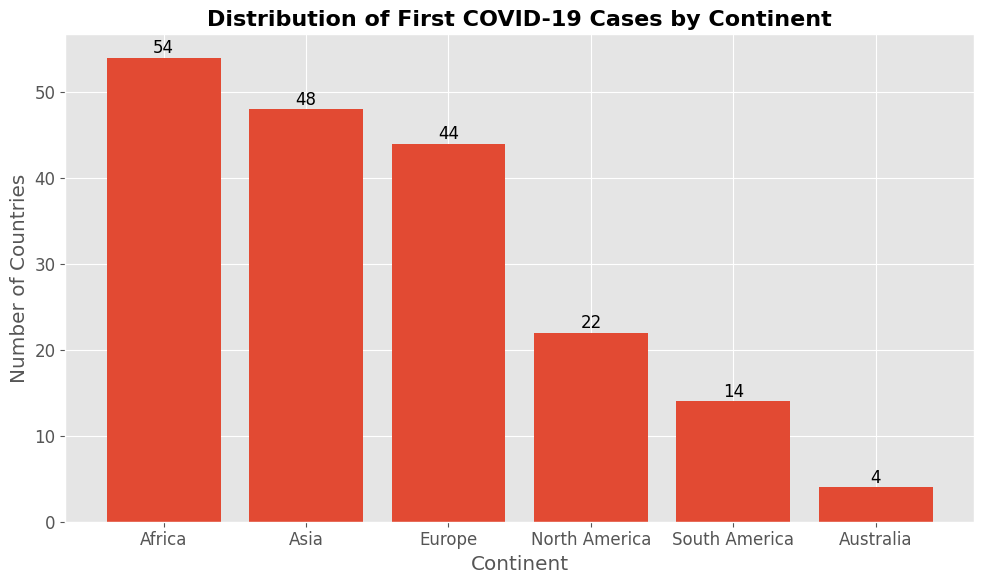

In [ ]:
# ==========================================================
# First Case Distribution by Continent
# ==========================================================

continent_cases = (
    df.groupby("Continent")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="Countries")
)

display(continent_cases)

continent_cases.to_csv(
    os.path.join(tables_folder, "FirstCaseByContinent.csv"),
    index=False
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    continent_cases["Continent"],
    continent_cases["Countries"]
)

plt.title("Distribution of First COVID-19 Cases by Continent",
          fontsize=16,
          weight='bold')

plt.xlabel("Continent")
plt.ylabel("Number of Countries")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        int(bar.get_height()),
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"FirstCaseByContinent.pdf"),
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(figures_folder,"FirstCaseByContinent.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

,Continent,Countries
0,Africa,45
1,Europe,43
2,Asia,41
3,North America,17
4,South America,12
5,Australia,2


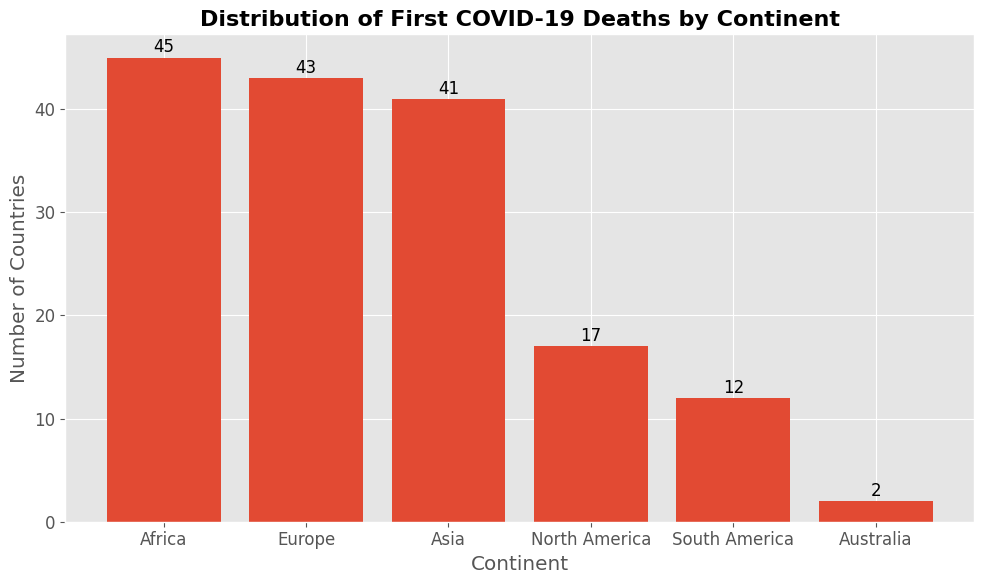

In [ ]:
death_continent = (
    df.dropna(subset=["Date of First Death(s)"])
      .groupby("Continent")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="Countries")
)

display(death_continent)

death_continent.to_csv(
    os.path.join(tables_folder,"FirstDeathByContinent.csv"),
    index=False
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    death_continent["Continent"],
    death_continent["Countries"]
)

plt.title("Distribution of First COVID-19 Deaths by Continent",
          fontsize=16,
          weight='bold')

plt.xlabel("Continent")
plt.ylabel("Number of Countries")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        int(bar.get_height()),
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"FirstDeathByContinent.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"FirstDeathByContinent.png"),
    dpi=300
)

plt.show()

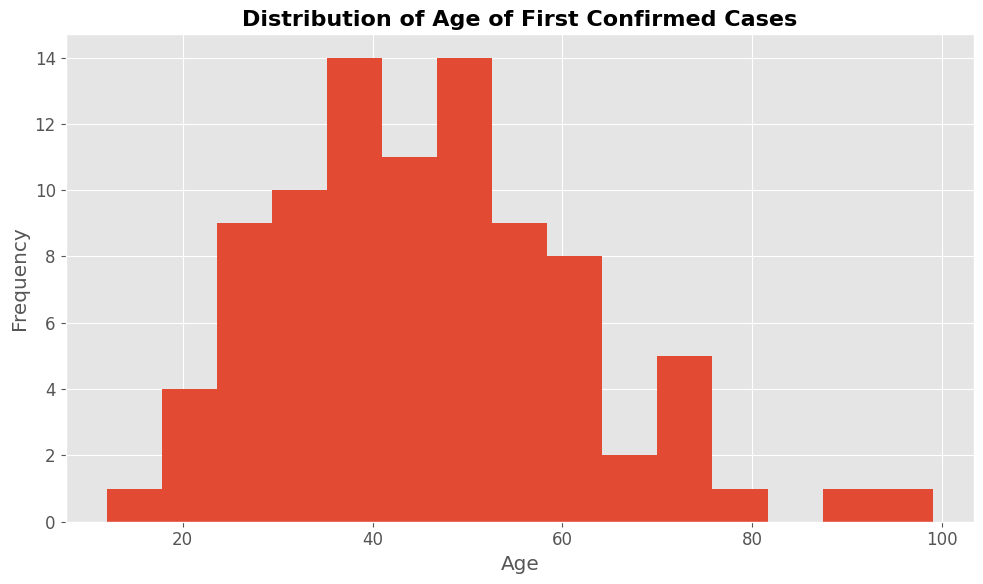

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Age of First Case(s)"].dropna(),
    bins=15
)

plt.title("Distribution of Age of First Confirmed Cases",
          fontsize=16,
          weight='bold')

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"AgeDistribution_FirstCases.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"AgeDistribution_FirstCases.png"),
    dpi=300
)

plt.show()

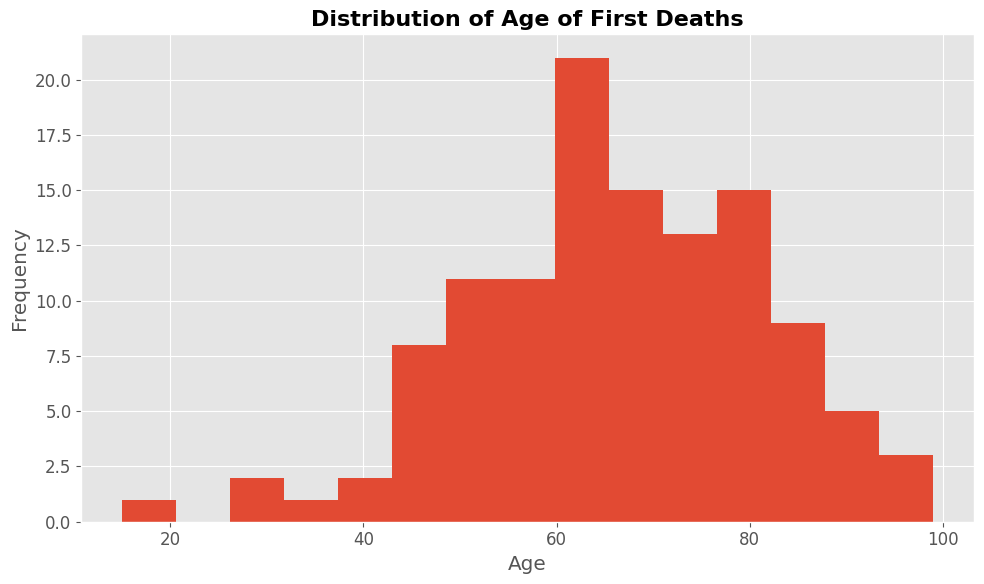

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Age of First Death(s)"].dropna(),
    bins=15
)

plt.title("Distribution of Age of First Deaths",
          fontsize=16,
          weight='bold')

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"AgeDistribution_FirstDeaths.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"AgeDistribution_FirstDeaths.png"),
    dpi=300
)

plt.show()

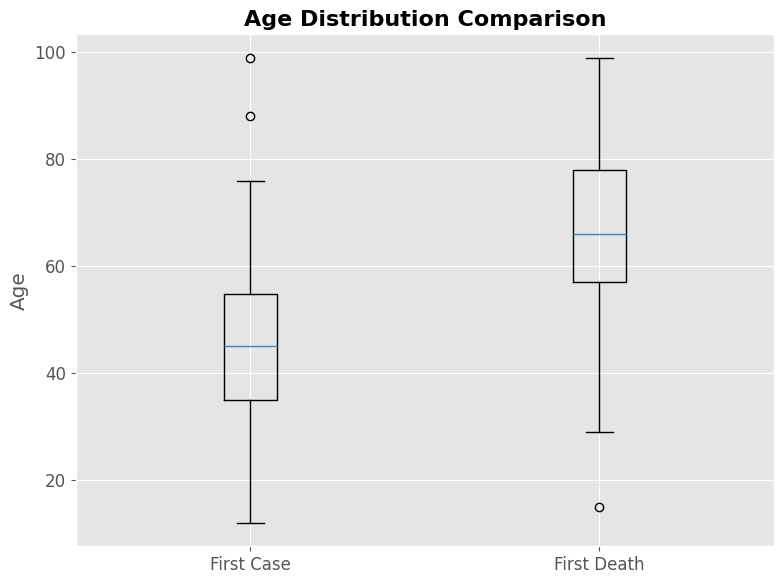

In [ ]:
plt.figure(figsize=(8,6))

plt.boxplot([
    df["Age of First Case(s)"].dropna(),
    df["Age of First Death(s)"].dropna()
])

plt.xticks(
    [1,2],
    ["First Case","First Death"]
)

plt.ylabel("Age")

plt.title("Age Distribution Comparison",
          fontsize=16,
          weight='bold')

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"AgeComparison_Boxplot.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"AgeComparison_Boxplot.png"),
    dpi=300
)

plt.show()

,Date of First Case(s),Countries
0,2019-11-17,1
1,2019-12-27,1
2,2020-01-13,2
3,2020-01-16,1
4,2020-01-20,1


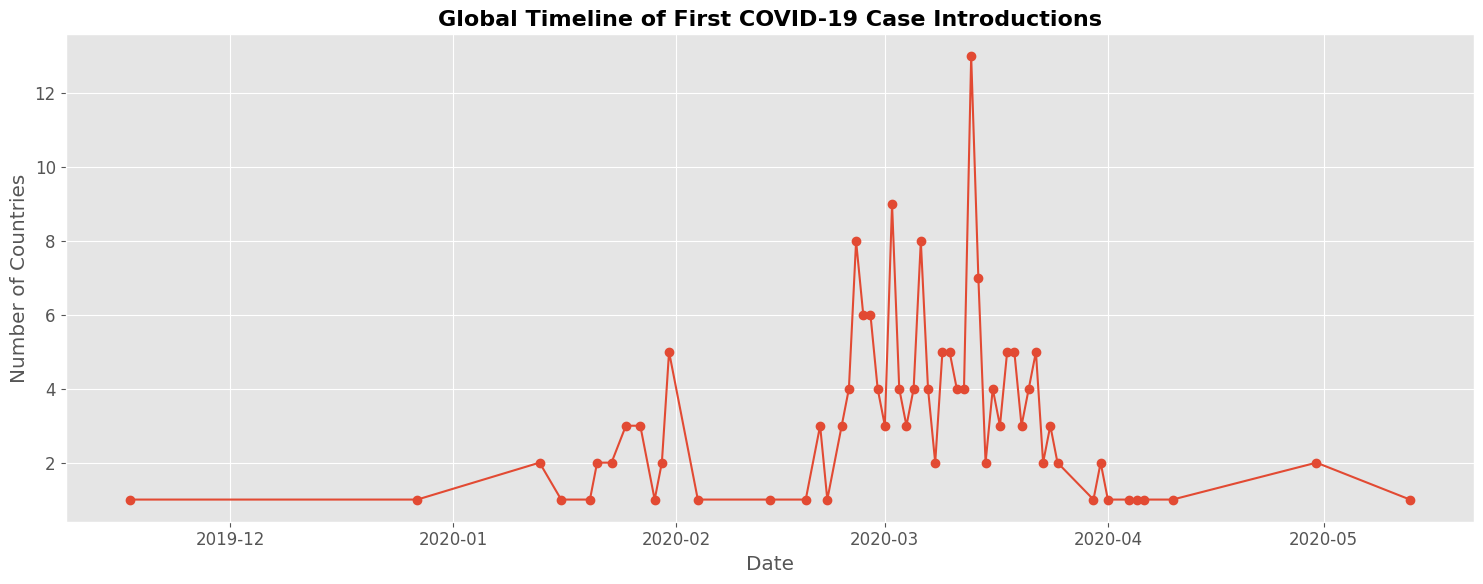

In [ ]:
timeline = (
    df.groupby("Date of First Case(s)")
      .size()
      .reset_index(name="Countries")
)

display(timeline.head())

timeline.to_csv(
    os.path.join(tables_folder,"Timeline_FirstCases.csv"),
    index=False
)

plt.figure(figsize=(15,6))

plt.plot(
    timeline["Date of First Case(s)"],
    timeline["Countries"],
    marker='o'
)

plt.title("Global Timeline of First COVID-19 Case Introductions",
          fontsize=16,
          weight='bold')

plt.xlabel("Date")

plt.ylabel("Number of Countries")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"GlobalTimeline.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"GlobalTimeline.png"),
    dpi=300
)

plt.show()

,Month,Countries
0,2019-11,1
1,2019-12,1
2,2020-01,22
3,2020-02,38
4,2020-03,116
5,2020-04,7
6,2020-05,1


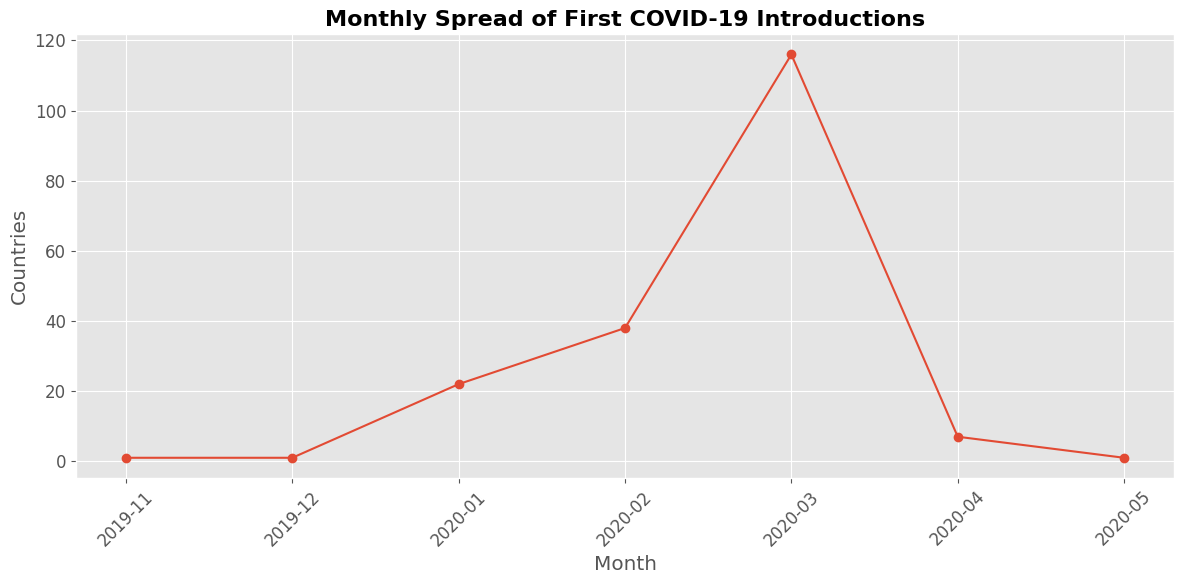

In [ ]:
df["Month"] = df["Date of First Case(s)"].dt.to_period("M")

monthly = (
    df.groupby("Month")
      .size()
      .reset_index(name="Countries")
)

monthly["Month"] = monthly["Month"].astype(str)

display(monthly)

monthly.to_csv(
    os.path.join(tables_folder,"MonthlySpread.csv"),
    index=False
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly["Month"],
    monthly["Countries"],
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Spread of First COVID-19 Introductions",
          fontsize=16,
          weight='bold')

plt.xlabel("Month")

plt.ylabel("Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"MonthlySpread.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"MonthlySpread.png"),
    dpi=300
)

plt.show()

,Week,Countries
0,2019-11-11/2019-11-17,1
1,2019-12-23/2019-12-29,1
2,2020-01-13/2020-01-19,3
3,2020-01-20/2020-01-26,8
4,2020-01-27/2020-02-02,11
5,2020-02-03/2020-02-09,1
6,2020-02-10/2020-02-16,1
7,2020-02-17/2020-02-23,5
8,2020-02-24/2020-03-01,34
9,2020-03-02/2020-03-08,34


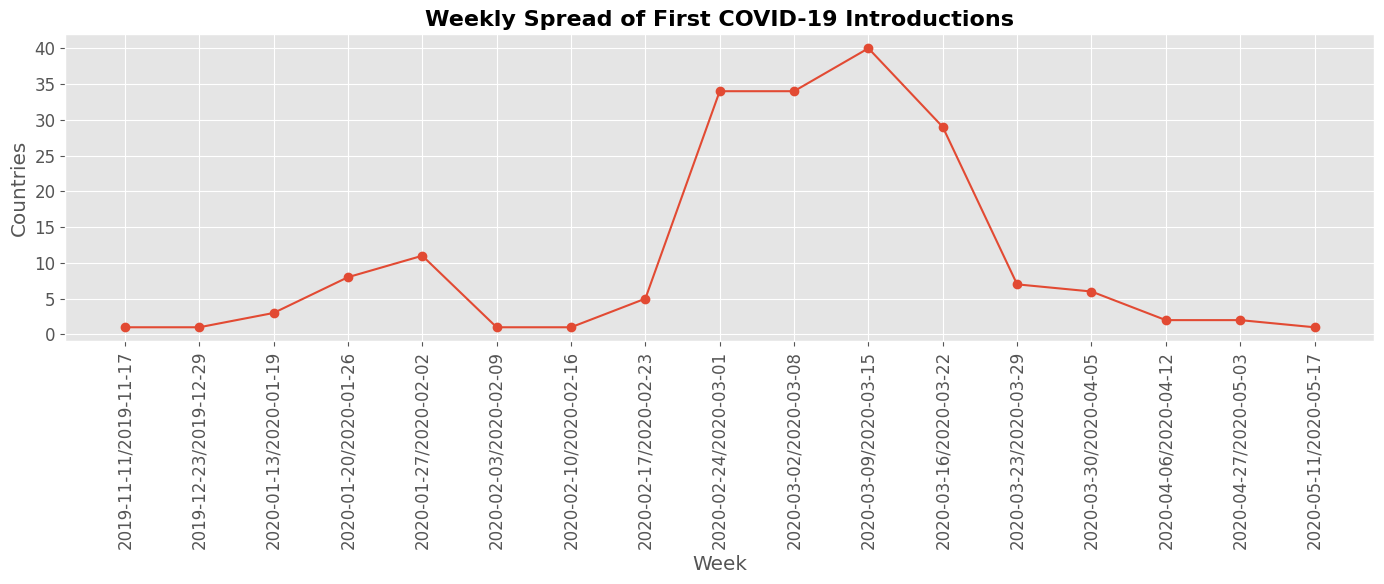

In [ ]:
df["Week"] = df["Date of First Case(s)"].dt.to_period("W")

weekly = (
    df.groupby("Week")
      .size()
      .reset_index(name="Countries")
)

weekly["Week"] = weekly["Week"].astype(str)

display(weekly)

weekly.to_csv(
    os.path.join(tables_folder,"WeeklySpread.csv"),
    index=False
)

plt.figure(figsize=(14,6))

plt.plot(
    weekly["Week"],
    weekly["Countries"],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Weekly Spread of First COVID-19 Introductions",
          fontsize=16,
          weight='bold')

plt.xlabel("Week")

plt.ylabel("Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"WeeklySpread.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"WeeklySpread.png"),
    dpi=300
)

plt.show()

In [ ]:
!pip install plotly -q

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
network_df = df[[
    "Country",
    "Last Visited Country(s) of Confirmed Case(s)"
]].copy()

network_df.columns = [
    "Destination",
    "Origin"
]

network_df = network_df.dropna()

network_df["Origin"] = network_df["Origin"].astype(str)
network_df["Destination"] = network_df["Destination"].astype(str)

display(network_df.head())


,Destination,Origin
0,China,Starting Country
2,Nepal,China
3,Thailand,China
4,Japan,China
5,South Korea,China


In [ ]:
network_df["Origin"] = network_df["Origin"].str.split(",")

network_df = network_df.explode("Origin")

network_df["Origin"] = network_df["Origin"].str.strip()

network_df.reset_index(drop=True, inplace=True)

display(network_df.head())

,Destination,Origin
0,China,Starting Country
1,Nepal,China
2,Thailand,China
3,Japan,China
4,South Korea,China


In [ ]:
G = nx.from_pandas_edgelist(
    network_df,
    source="Origin",
    target="Destination",
    create_using=nx.DiGraph()
)

print("Network Created Successfully!")

Network Created Successfully!


In [ ]:
print("="*60)

print("NETWORK STATISTICS")

print("="*60)

print("Number of Nodes :", G.number_of_nodes())

print("Number of Edges :", G.number_of_edges())

print("Network Density :", nx.density(G))

print("Connected Components :", nx.number_weakly_connected_components(G))

NETWORK STATISTICS
Number of Nodes : 178
Number of Edges : 202
Network Density : 0.006411477178950041
Connected Components : 2


In [ ]:
origin_frequency = (
    network_df["Origin"]
    .value_counts()
    .reset_index()
)

origin_frequency.columns = [
    "Origin Country",
    "Frequency"
]

display(origin_frequency.head(20))

origin_frequency.to_csv(
    os.path.join(
        tables_folder,
        "OriginCountryFrequency.csv"
    ),
    index=False
)

,Origin Country,Frequency
0,Italy,50
1,China,25
2,Iran,17
3,United Kingdom,15
4,France,14
5,United States,10
6,Spain,10
7,Germany,4
8,United Arab Emirates,4
9,Belgium,4


In [ ]:
destination_frequency = (
    network_df["Destination"]
    .value_counts()
    .reset_index()
)

destination_frequency.columns = [
    "Destination Country",
    "Frequency"
]

display(destination_frequency.head(20))

destination_frequency.to_csv(
    os.path.join(
        tables_folder,
        "DestinationCountryFrequency.csv"
    ),
    index=False
)

,Destination Country,Frequency
0,Togo,4
1,Niger,3
2,Peru,3
3,West Bank and Gaza,3
4,Bahrain,2
5,New Zealand,2
6,Portugal,2
7,Ukraine,2
8,Cyprus,2
9,Georgia,2


In [ ]:
degree = nx.degree_centrality(G)

degree_df = (
    pd.DataFrame.from_dict(
        degree,
        orient="index",
        columns=["Degree Centrality"]
    )
    .sort_values(
        by="Degree Centrality",
        ascending=False
    )
)

display(degree_df.head(20))

degree_df.to_csv(
    os.path.join(
        tables_folder,
        "DegreeCentrality.csv"
    )
)

,Degree Centrality
Italy,0.288136
China,0.146893
Iran,0.101695
United Kingdom,0.090395
France,0.079096
Spain,0.062147
United States,0.062147
Germany,0.028249
Switzerland,0.028249
United Arab Emirates,0.028249


In [ ]:
betweenness = nx.betweenness_centrality(G)

betweenness_df = (
    pd.DataFrame.from_dict(
        betweenness,
        orient="index",
        columns=["Betweenness"]
    )
    .sort_values(
        by="Betweenness",
        ascending=False
    )
)

display(betweenness_df.head(20))

betweenness_df.to_csv(
    os.path.join(
        tables_folder,
        "BetweennessCentrality.csv"
    )
)

,Betweenness
China,0.004911
Italy,0.003499
Iran,0.001252
Spain,0.000995
Germany,0.000867
United Kingdom,0.000835
United States,0.000546
Saudi Arabia,0.000417
Switzerland,0.000353
Belgium,0.000321


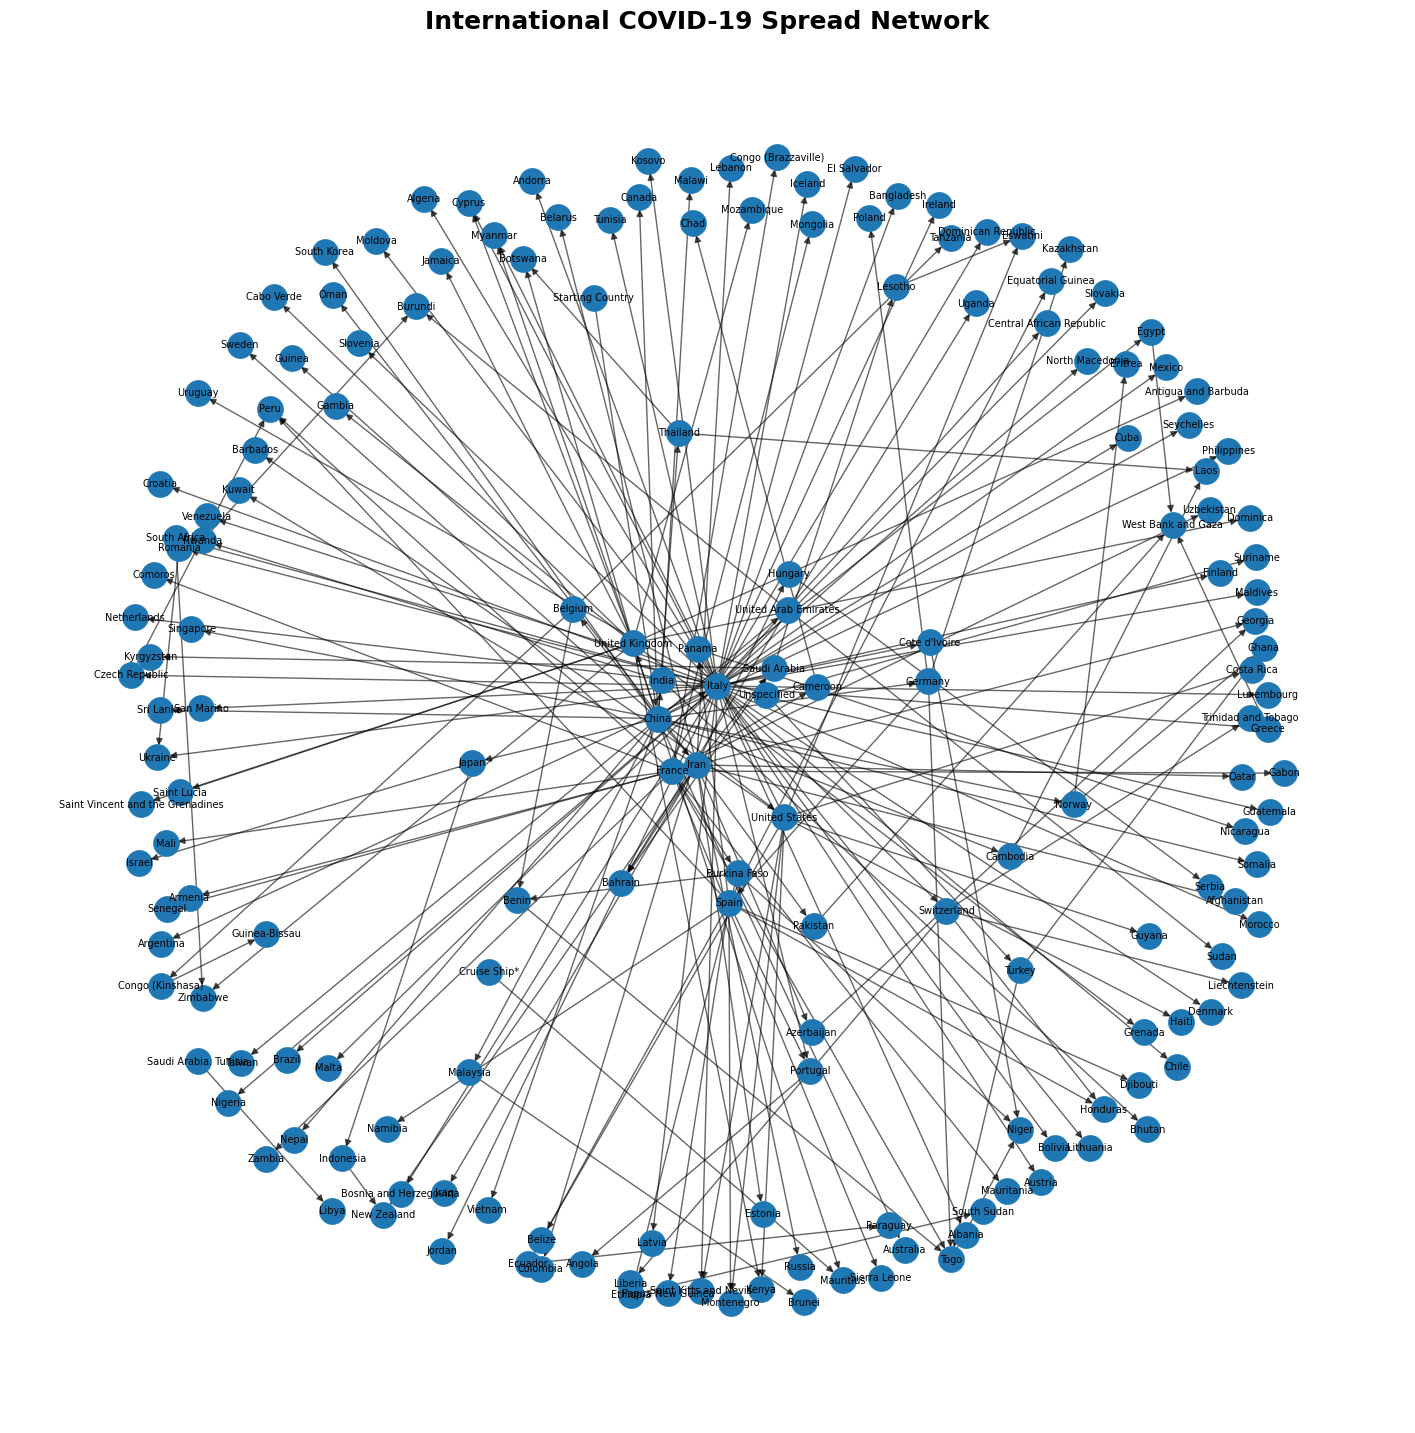

In [ ]:
plt.figure(figsize=(18,18))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=350
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    alpha=0.6
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=7
)

plt.title(
    "International COVID-19 Spread Network",
    fontsize=18,
    weight="bold"
)

plt.axis("off")

plt.savefig(
    os.path.join(
        figures_folder,
        "NetworkGraph.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        figures_folder,
        "NetworkGraph.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
pos = nx.spring_layout(G, seed=42)

edge_x = []
edge_y = []

for edge in G.edges():

    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]

    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(width=0.5),
    hoverinfo='none'
)

node_x = []
node_y = []
text = []

for node in G.nodes():

    x, y = pos[node]

    node_x.append(x)
    node_y.append(y)
    text.append(node)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    text=text,
    textposition="top center",
    hoverinfo='text',
    marker=dict(size=10)
)

fig = go.Figure(
    data=[edge_trace,node_trace]
)

fig.update_layout(
    title="Interactive International Spread Network",
    showlegend=False
)

fig.show()

In [ ]:
network_df.to_csv(
    os.path.join(
        tables_folder,
        "NetworkEdges.csv"
    ),
    index=False
)

In [ ]:
# ==========================================================
# Create Temporal Features
# ==========================================================

df["Year"] = df["Date of First Case(s)"].dt.year
df["Month"] = df["Date of First Case(s)"].dt.month
df["Month_Name"] = df["Date of First Case(s)"].dt.strftime("%b")
df["Week"] = df["Date of First Case(s)"].dt.isocalendar().week
df["DayOfYear"] = df["Date of First Case(s)"].dt.dayofyear

print("Temporal Features Created Successfully.")

Temporal Features Created Successfully.


,Year,Countries
0,2019,2
1,2020,184


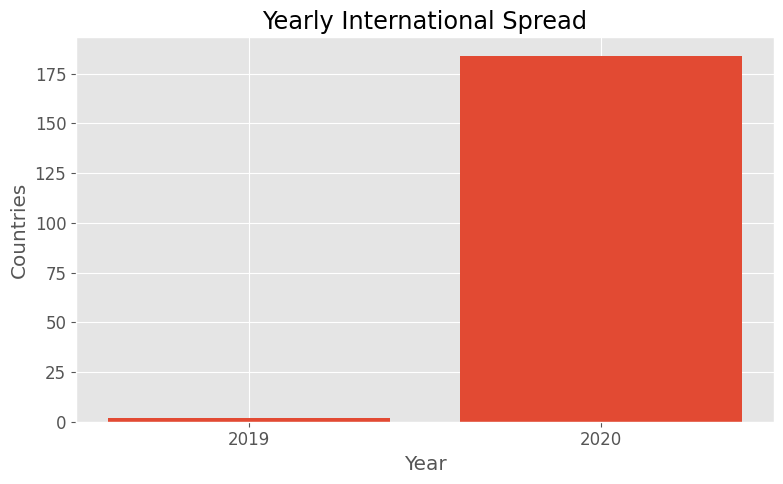

In [ ]:
yearly = (
    df.groupby("Year")
      .size()
      .reset_index(name="Countries")
)

display(yearly)

yearly.to_csv(
    os.path.join(tables_folder,"YearlySpread.csv"),
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(yearly["Year"].astype(str), yearly["Countries"])

plt.title("Yearly International Spread")

plt.xlabel("Year")

plt.ylabel("Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"YearlySpread.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"YearlySpread.png"),
    dpi=300
)

plt.show()

,Month_Name,Countries
0,Jan,22.0
1,Feb,38.0
2,Mar,116.0
3,Apr,7.0
4,May,1.0
5,Jun,0.0
6,Jul,0.0
7,Aug,0.0
8,Sep,0.0
9,Oct,0.0


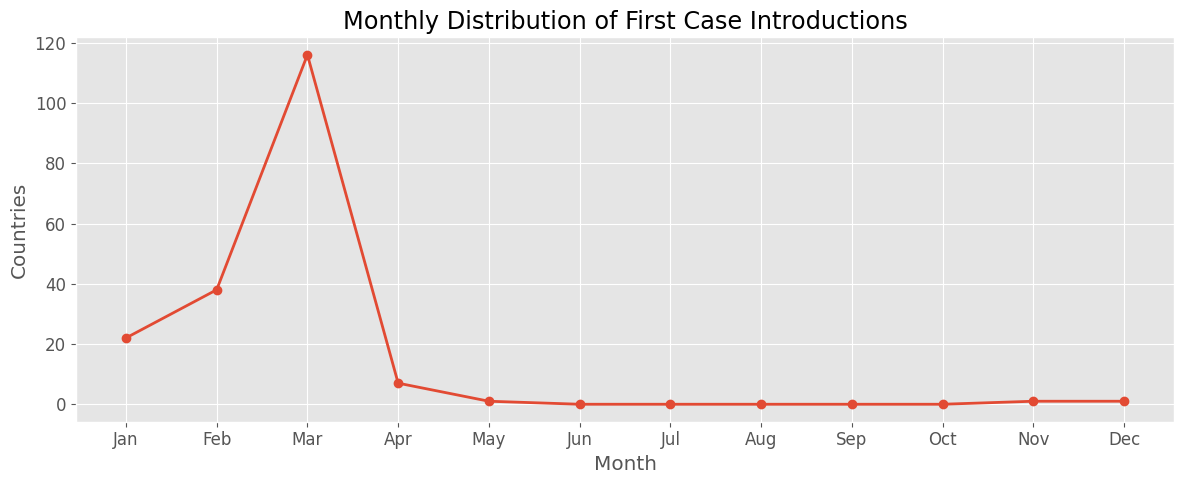

In [ ]:
month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly = (
    df.groupby("Month_Name")
      .size()
      .reindex(month_order)
      .fillna(0)
      .reset_index(name="Countries")
)

display(monthly)

monthly.to_csv(
    os.path.join(tables_folder,"MonthlySpread.csv"),
    index=False
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month_Name"],
    monthly["Countries"],
    marker="o",
    linewidth=2
)

plt.grid(True)

plt.title("Monthly Distribution of First Case Introductions")

plt.xlabel("Month")

plt.ylabel("Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"MonthlySpread.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"MonthlySpread.png"),
    dpi=300
)

plt.show()

,Week,Countries
0,3,3
1,4,8
2,5,11
3,6,1
4,7,1
5,8,5
6,9,34
7,10,34
8,11,40
9,12,29


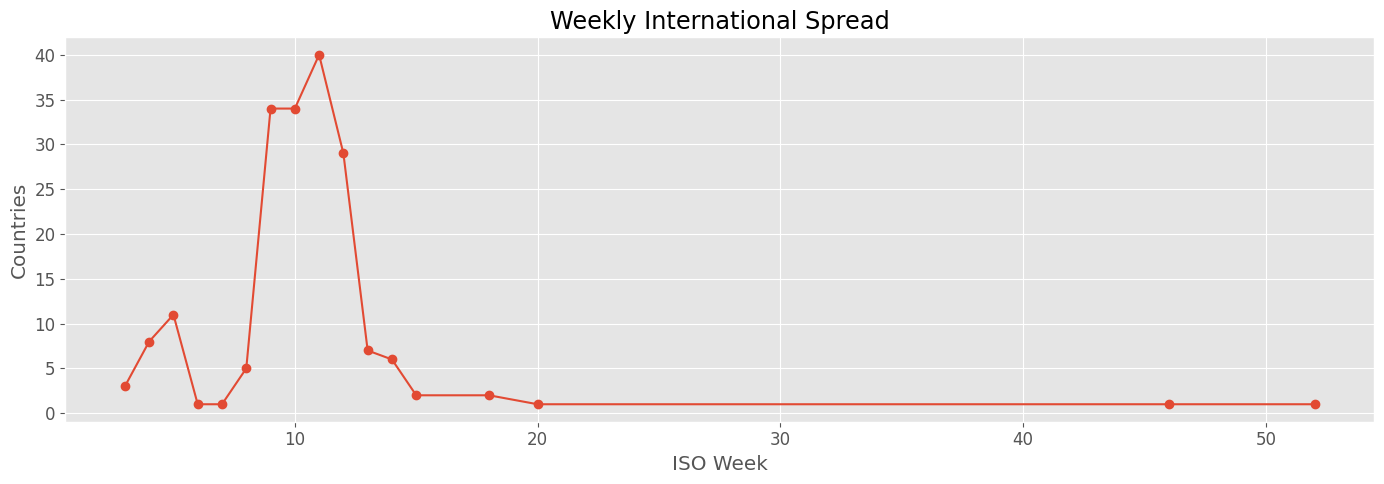

In [ ]:
weekly = (
    df.groupby("Week")
      .size()
      .reset_index(name="Countries")
)

display(weekly)

weekly.to_csv(
    os.path.join(tables_folder,"WeeklySpread.csv"),
    index=False
)

plt.figure(figsize=(14,5))

plt.plot(
    weekly["Week"],
    weekly["Countries"],
    marker="o"
)

plt.grid(True)

plt.title("Weekly International Spread")

plt.xlabel("ISO Week")

plt.ylabel("Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"WeeklySpread.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"WeeklySpread.png"),
    dpi=300
)

plt.show()

,Date of First Case(s),Countries,Cumulative
0,2019-11-17,1,1
1,2019-12-27,1,2
2,2020-01-13,2,4
3,2020-01-16,1,5
4,2020-01-20,1,6


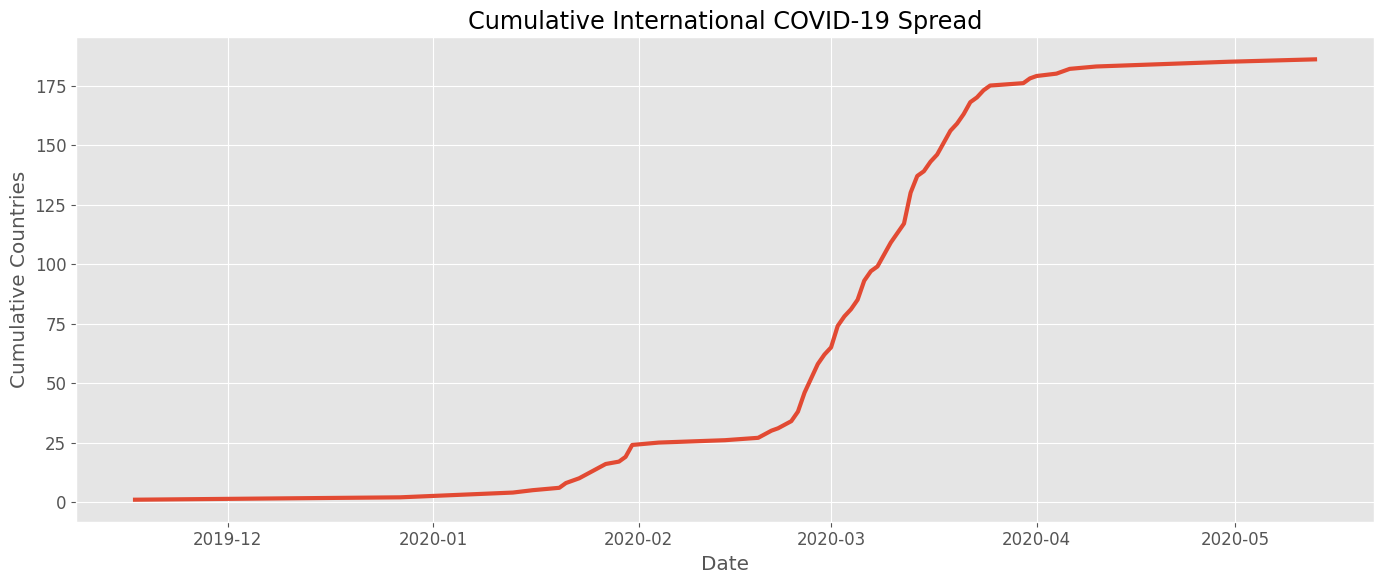

In [ ]:
timeline = (
    df.groupby("Date of First Case(s)")
      .size()
      .reset_index(name="Countries")
      .sort_values("Date of First Case(s)")
)

timeline["Cumulative"] = timeline["Countries"].cumsum()

display(timeline.head())

timeline.to_csv(
    os.path.join(tables_folder,"GlobalTimeline.csv"),
    index=False
)

plt.figure(figsize=(14,6))

plt.plot(
    timeline["Date of First Case(s)"],
    timeline["Cumulative"],
    linewidth=3
)

plt.grid(True)

plt.title("Cumulative International COVID-19 Spread")

plt.xlabel("Date")

plt.ylabel("Cumulative Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"CumulativeSpread.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"CumulativeSpread.png"),
    dpi=300
)

plt.show()

,Country,Days_To_First_Death
0,China,NaN
1,France,50.0
2,Nepal,124.0
3,Thailand,48.0
4,Japan,28.0


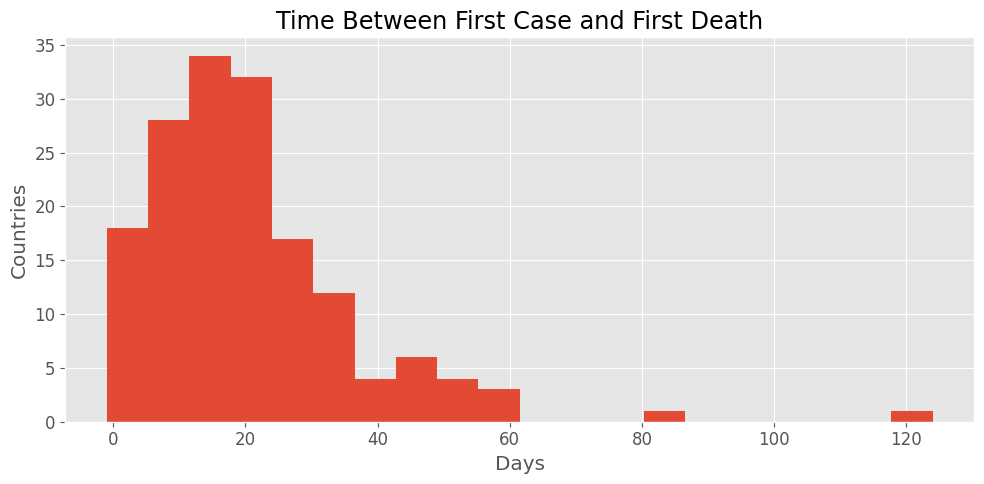

In [ ]:
df["Days_To_First_Death"] = (
    df["Date of First Death(s)"] -
    df["Date of First Case(s)"]
).dt.days

display(df[[
    "Country",
    "Days_To_First_Death"
]].head())

plt.figure(figsize=(10,5))

plt.hist(
    df["Days_To_First_Death"].dropna(),
    bins=20
)

plt.title("Time Between First Case and First Death")

plt.xlabel("Days")

plt.ylabel("Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(figures_folder,"DaysToDeath.pdf"),
    dpi=300
)

plt.savefig(
    os.path.join(figures_folder,"DaysToDeath.png"),
    dpi=300
)

plt.show()

In [ ]:
continent_time = (
    df.groupby(["Month_Name","Continent"])
      .size()
      .reset_index(name="Countries")
)

continent_time["Month_Name"] = pd.Categorical(
    continent_time["Month_Name"],
    categories=month_order,
    ordered=True
)

continent_time = continent_time.sort_values("Month_Name")

continent_time.to_csv(
    os.path.join(tables_folder,"ContinentTimeline.csv"),
    index=False
)

display(continent_time.head())

,Month_Name,Continent,Countries
10,Jan,Australia,1
9,Jan,Asia,14
11,Jan,Europe,5
12,Jan,North America,2
3,Feb,Africa,3


In [ ]:
heatmap = pd.pivot_table(
    df,
    index="Continent",
    columns="Month_Name",
    values="Country",
    aggfunc="count"
)

heatmap = heatmap.reindex(columns=month_order)

display(heatmap)

heatmap.to_csv(
    os.path.join(tables_folder,"MonthlyHeatmap.csv")
)

Month_Name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Continent,,,,,,,,,,,,
Africa,NaN,3.0,45.0,5.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asia,14.0,12.0,19.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
Australia,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Europe,5.0,19.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
North America,2.0,1.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South America,NaN,2.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
top_dates = (
    timeline.sort_values(
        "Countries",
        ascending=False
    )
    .head(10)
)

display(top_dates)

top_dates.to_csv(
    os.path.join(
        tables_folder,
        "PeakIntroductionDates.csv"
    ),
    index=False
)

,Date of First Case(s),Countries,Cumulative
35,2020-03-13,13,130
24,2020-03-02,9,74
19,2020-02-26,8,46
28,2020-03-06,8,93
36,2020-03-14,7,137
21,2020-02-28,6,58
20,2020-02-27,6,52
32,2020-03-10,5,109
11,2020-01-31,5,24
41,2020-03-19,5,156


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/COVID/Dataset_A_Clean_Country_Corrected.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
print(df["Country"].nunique())
print(network_df["Origin"].nunique())

G = nx.from_pandas_edgelist(
    network_df.dropna(subset=["Origin"]),
    source="Origin",
    target="Destination",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

186
45
Nodes: 178
Edges: 202
